# Gym Performance & Fitness Prediction

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('../data/gym_members_exercise_tracking.csv')
df.head()

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,56,Male,88.3,1.71,180,157,60,1.69,1313.0,Yoga,12.6,3.5,4,3,30.20
1,46,Female,74.9,1.53,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,32.00
2,32,Female,68.1,1.66,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,24.71
3,25,Male,53.2,1.70,190,164,56,0.59,532.0,Strength,28.8,2.1,3,1,18.41
4,38,Male,46.1,1.79,188,158,68,0.64,556.0,Strength,29.2,2.8,3,1,14.39


In [3]:
print(df.shape)
df.info()

(973, 15)
<class 'pandas.DataFrame'>
RangeIndex: 973 entries, 0 to 972
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            973 non-null    int64  
 1   Gender                         973 non-null    str    
 2   Weight (kg)                    973 non-null    float64
 3   Height (m)                     973 non-null    float64
 4   Max_BPM                        973 non-null    int64  
 5   Avg_BPM                        973 non-null    int64  
 6   Resting_BPM                    973 non-null    int64  
 7   Session_Duration (hours)       973 non-null    float64
 8   Calories_Burned                973 non-null    float64
 9   Workout_Type                   973 non-null    str    
 10  Fat_Percentage                 973 non-null    float64
 11  Water_Intake (liters)          973 non-null    float64
 12  Workout_Frequency (days/week)  973 non-null    int6

In [4]:
df.isnull().sum()

Age                              0
Gender                           0
Weight (kg)                      0
Height (m)                       0
Max_BPM                          0
Avg_BPM                          0
Resting_BPM                      0
Session_Duration (hours)         0
Calories_Burned                  0
Workout_Type                     0
Fat_Percentage                   0
Water_Intake (liters)            0
Workout_Frequency (days/week)    0
Experience_Level                 0
BMI                              0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(0)

##Data Quality Check
- shape: 973 rows, 15 columns
- No missing values
- No duplicated rows

In [6]:
df.describe()

,Age,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
count,973.000000,973.000000,973.00000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000
mean,38.683453,73.854676,1.72258,179.883864,143.766701,62.223022,1.256423,905.422405,24.976773,2.626619,3.321686,1.809866,24.912127
std,12.180928,21.207500,0.12772,11.525686,14.345101,7.327060,0.343033,272.641516,6.259419,0.600172,0.913047,0.739693,6.660879
min,18.000000,40.000000,1.50000,160.000000,120.000000,50.000000,0.500000,303.000000,10.000000,1.500000,2.000000,1.000000,12.320000
25%,28.000000,58.100000,1.62000,170.000000,131.000000,56.000000,1.040000,720.000000,21.300000,2.200000,3.000000,1.000000,20.110000
50%,40.000000,70.000000,1.71000,180.000000,143.000000,62.000000,1.260000,893.000000,26.200000,2.600000,3.000000,2.000000,24.160000
75%,49.000000,86.000000,1.80000,190.000000,156.000000,68.000000,1.460000,1076.000000,29.300000,3.100000,4.000000,2.000000,28.560000
max,59.000000,129.900000,2.00000,199.000000,169.000000,74.000000,2.000000,1783.000000,35.000000,3.700000,5.000000,3.000000,49.840000


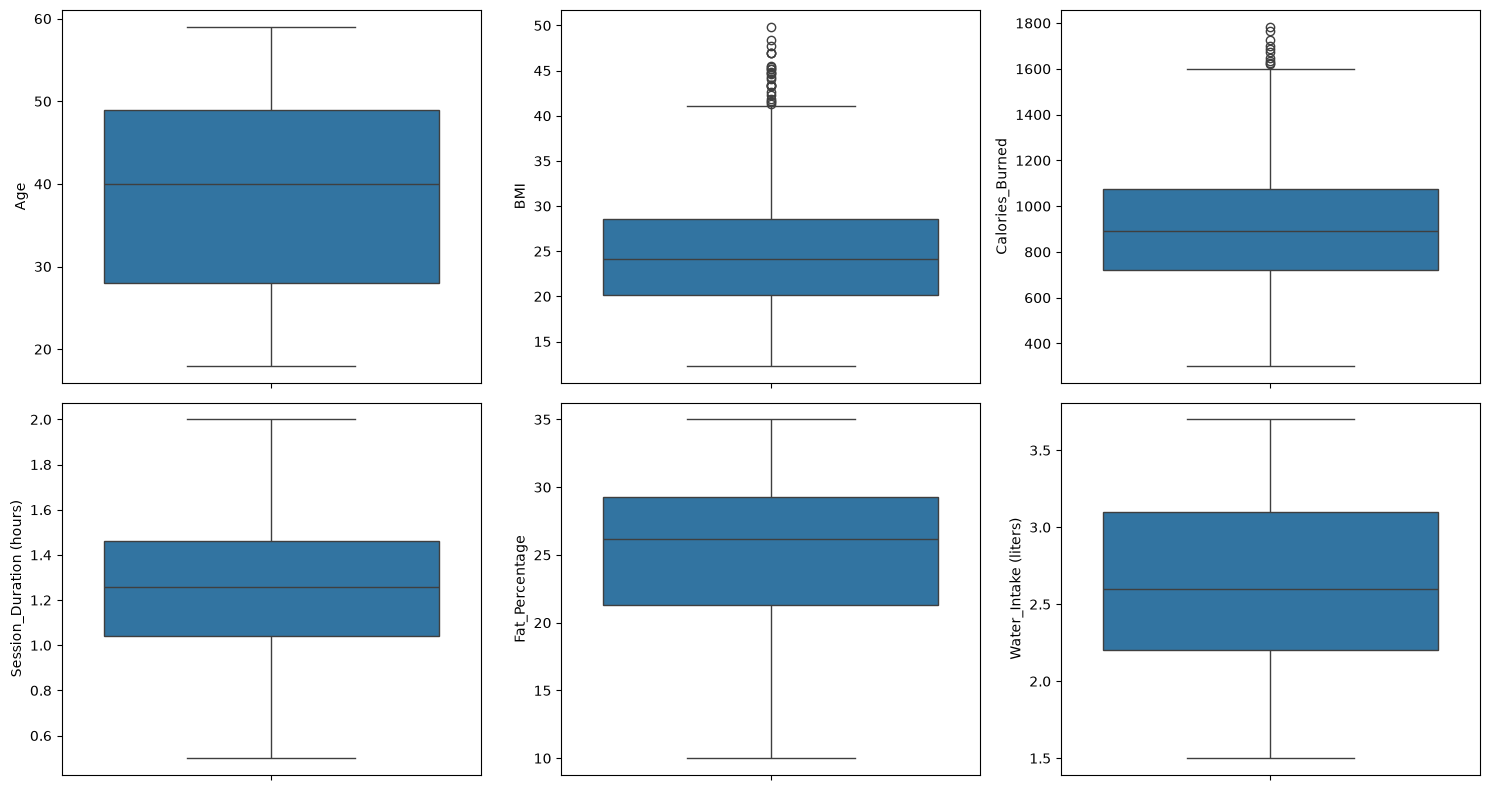

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

sns.boxplot(y=df['Age'], ax=axes[0, 0])
sns.boxplot(y=df['BMI'], ax=axes[0, 1])
sns.boxplot(y=df['Calories_Burned'], ax=axes[0, 2])
sns.boxplot(y=df['Session_Duration (hours)'], ax=axes[1, 0])
sns.boxplot(y=df['Fat_Percentage'], ax=axes[1, 1])
sns.boxplot(y=df['Water_Intake (liters)'], ax=axes[1, 2])

plt.tight_layout()
plt.show()

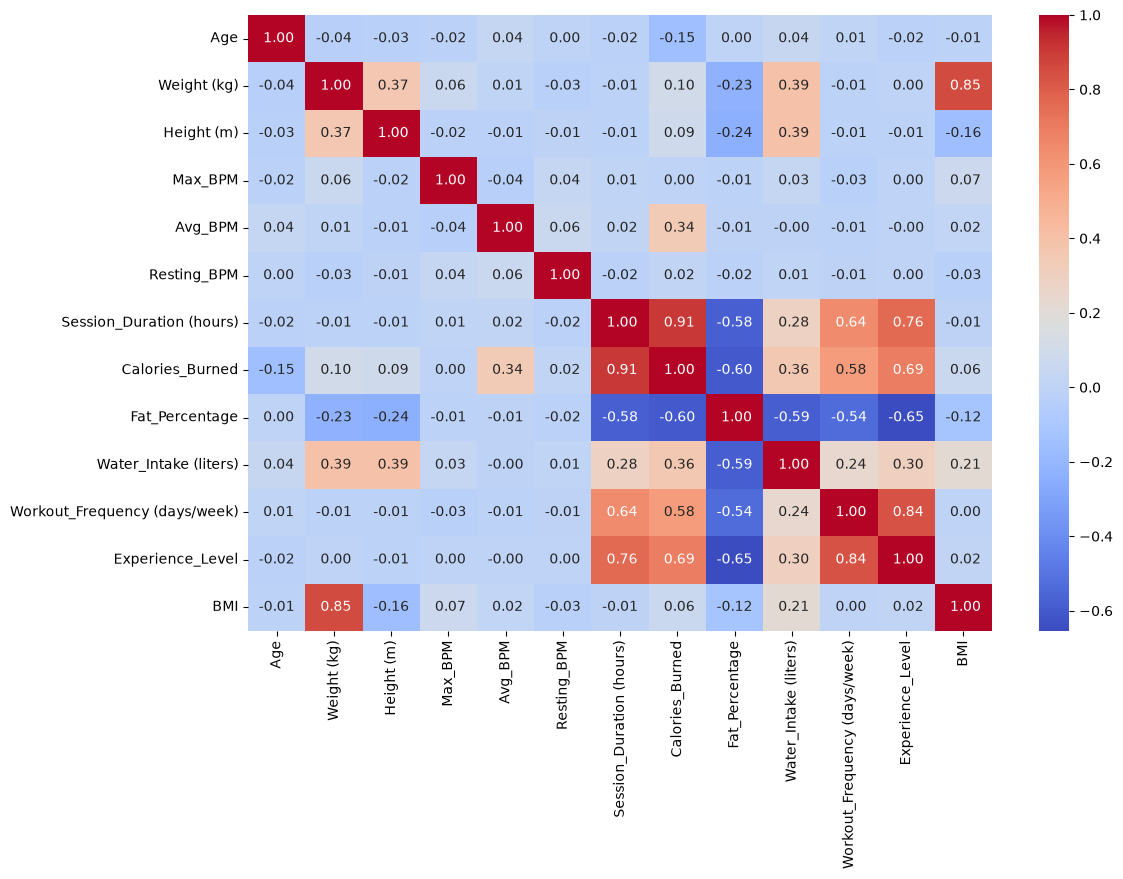

In [8]:
plt.figure(figsize=(12, 8))
numeric_df = df.select_dtypes(include=['int64', 'float64'])
sns.heatmap(numeric_df.corr(), annot=True, fmt=' .2f', cmap='coolwarm')
plt.show()

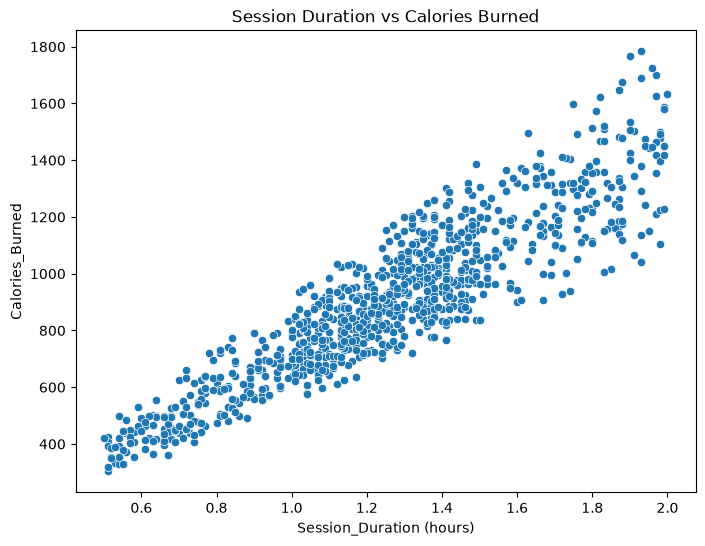

In [9]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=df['Session_Duration (hours)'], y=df['Calories_Burned'])
plt.title('Session Duration vs Calories Burned')
plt.show()

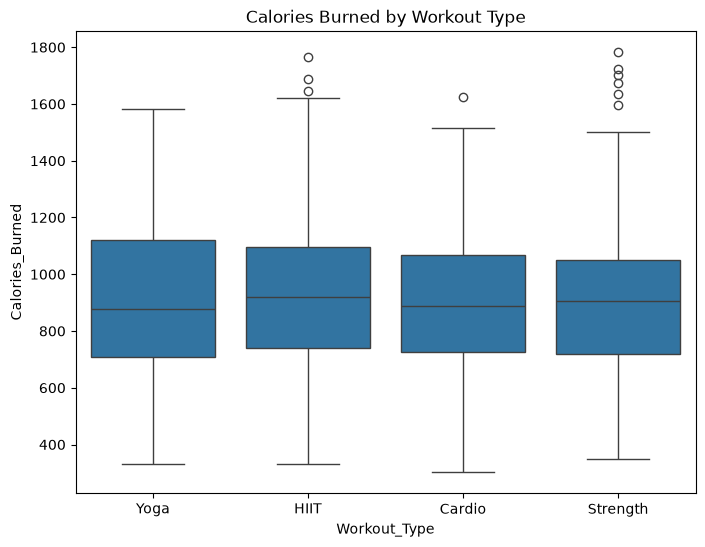

In [10]:
plt.figure(figsize=(8, 6))
sns.boxplot(x=df['Workout_Type'], y=df['Calories_Burned'])
plt.title('Calories Burned by Workout Type')
plt.show()

## Additional visualizations

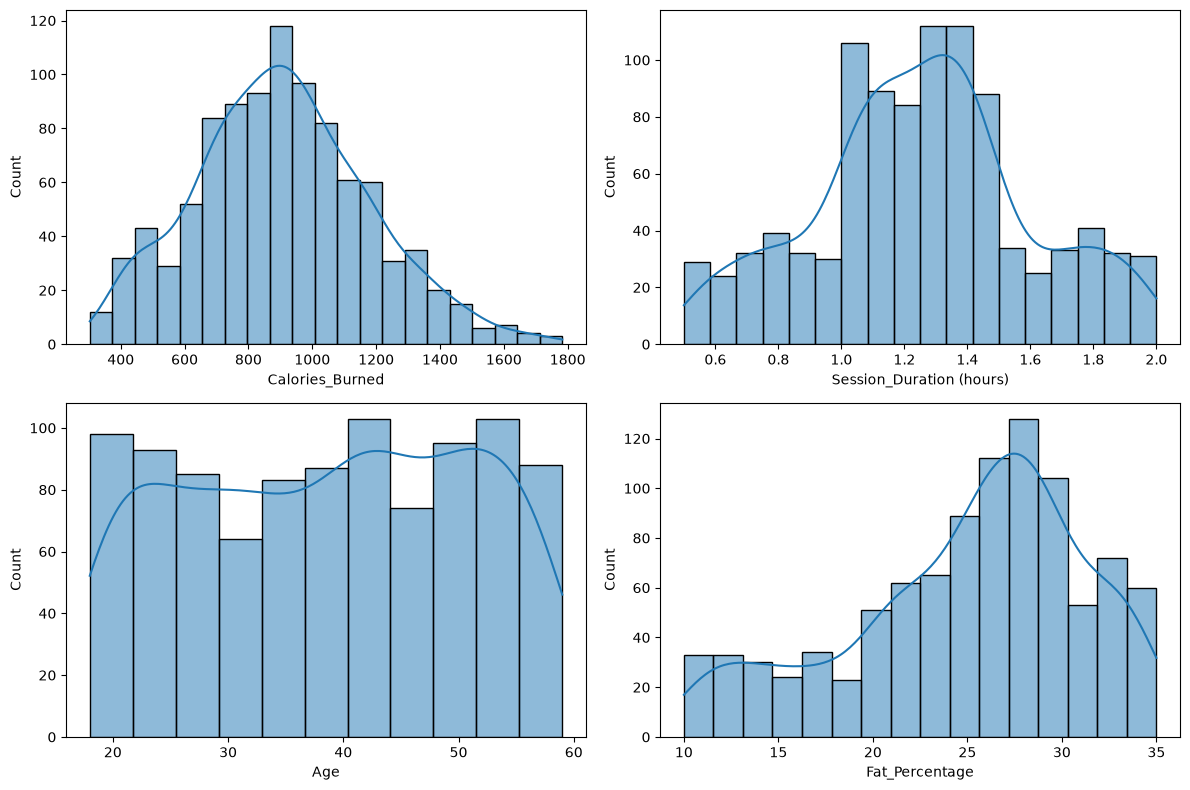

In [11]:
import os
os.makedirs('../images', exist_ok=True)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
sns.histplot(df['Calories_Burned'], kde=True, ax=axes[0, 0])
sns.histplot(df['Session_Duration (hours)'], kde=True, ax=axes[0, 1])
sns.histplot(df['Age'], kde=True, ax=axes[1, 0])
sns.histplot(df['Fat_Percentage'], kde=True, ax=axes[1, 1])

plt.tight_layout()
plt.savefig('../images/distributions.png', dpi=150)
plt.show()

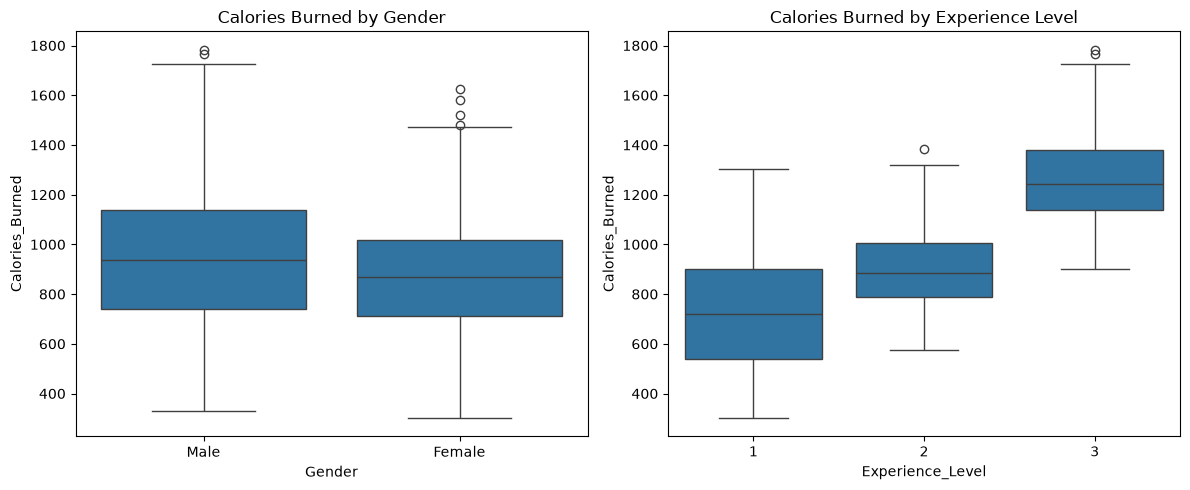

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(x='Gender', y='Calories_Burned', data=df, ax=axes[0])
axes[0].set_title('Calories Burned by Gender')

sns.boxplot(x='Experience_Level', y='Calories_Burned', data=df, ax=axes[1])
axes[1].set_title('Calories Burned by Experience Level')

plt.tight_layout()
plt.savefig('../images/gender_experience.png', dpi=150)
plt.show()

                  Session_Duration (hours)  Calories_Burned
Experience_Level                                           
1                                     1.01           726.38
2                                     1.25           901.92
3                                     1.76          1265.34


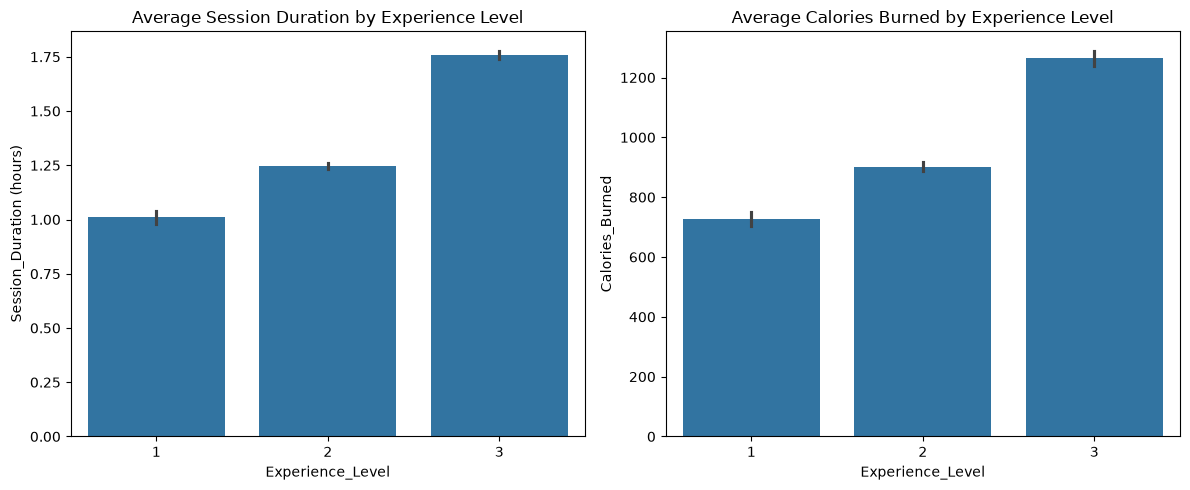

In [13]:
summary = df.groupby('Experience_Level')[['Session_Duration (hours)', 'Calories_Burned']].mean().round(2)
print(summary)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(x='Experience_Level', y='Session_Duration (hours)', data=df, ax=axes[0])
axes[0].set_title('Average Session Duration by Experience Level')

sns.barplot(x='Experience_Level', y='Calories_Burned', data=df, ax=axes[1])
axes[1].set_title('Average Calories Burned by Experience Level')

plt.tight_layout()
plt.savefig('../images/experience_duration.png', dpi=150)
plt.show()

                  count   mean   std    min    25%    50%    75%    max
Experience_Level                                                       
1                 376.0  718.8  88.8  540.3  644.6  719.7  775.3  924.4
2                 406.0  722.4  84.1  544.4  660.4  715.2  784.3  929.5
3                 191.0  719.4  89.6  539.9  648.1  715.1  786.8  929.5


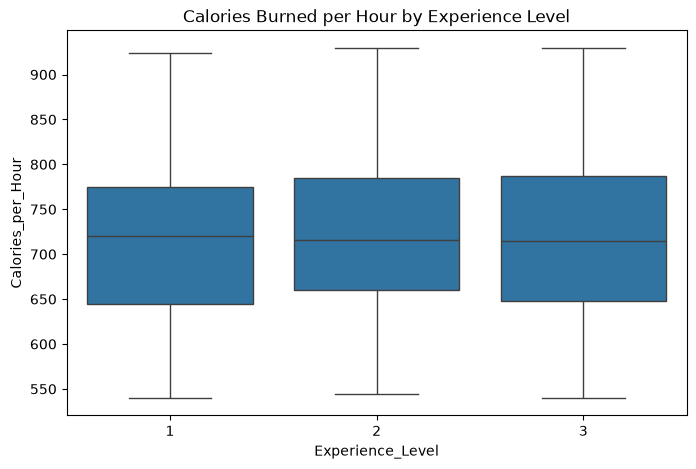

In [14]:
eda_df = df.copy()
eda_df['Calories_per_Hour'] = eda_df['Calories_Burned'] / eda_df['Session_Duration (hours)']

print(eda_df.groupby('Experience_Level')['Calories_per_Hour'].describe().round(1))

plt.figure(figsize=(8, 5))
sns.boxplot(x='Experience_Level', y='Calories_per_Hour', data=eda_df)
plt.title('Calories Burned per Hour by Experience Level')
plt.savefig('../images/calories_per_hour.png', dpi=150)
plt.show()

In [15]:
df_model = df.drop(columns=['BMI'])

df_model = pd.get_dummies(df_model, columns=['Gender', 'Workout_Type'], drop_first=True)

df_model.head()

,Age,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,Gender_Male,Workout_Type_HIIT,Workout_Type_Strength,Workout_Type_Yoga
0,56,88.3,1.71,180,157,60,1.69,1313.0,12.6,3.5,4,3,True,False,False,True
1,46,74.9,1.53,179,151,66,1.30,883.0,33.9,2.1,4,2,False,True,False,False
2,32,68.1,1.66,167,122,54,1.11,677.0,33.4,2.3,4,2,False,False,False,False
3,25,53.2,1.70,190,164,56,0.59,532.0,28.8,2.1,3,1,True,False,True,False
4,38,46.1,1.79,188,158,68,0.64,556.0,29.2,2.8,3,1,True,False,True,False


In [16]:
X = df_model.drop(columns=['Calories_Burned'])
y = df_model['Calories_Burned']

print(X.shape)
print(y.shape)

(973, 15)
(973,)


In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape)
print(X_test.shape)

(778, 15)
(195, 15)


In [18]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](15,)","[-3.3 , 0.08,11.01,...,-4.69,-3.45,-8.76]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](15,)","['Age','Weight (kg)','Height (m)',...,'Workout_Type_HIIT', 'Workout_Type_Strength','Workout_Type_Yoga']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-852.7
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,15
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(15)


In [19]:
y_pred = model.predict(X_test)

print(y_pred[:5])
print(y_test[:5].values)

[ 914.25792268 1417.95906719  956.57212123 1109.70272725 1501.18269155]
[ 929. 1401.  925. 1155. 1587.]


In [20]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f'MAE: {mae:.2f}')
print(f'MSE: {mse:.2f}')
print(f'RMSE: {rmse:.2f}')
print(f'R²: {r2:.4f}')

MAE: 30.39
MSE: 1665.25
RMSE: 40.81
R²: 0.9800


In [21]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print(f'MAE: {mae_rf:.2f}')
print(f'RMSE: {rmse_rf:.2f}')
print(f'R²: {r2_rf:.4f}')

MAE: 35.91
RMSE: 47.24
R²: 0.9732


In [22]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
}).sort_values(by='Coefficient', ascending=False)

print(coefficients)

                          Feature  Coefficient
6        Session_Duration (hours)   712.765065
11                    Gender_Male    84.617309
2                      Height (m)    11.007572
4                         Avg_BPM     6.156481
9   Workout_Frequency (days/week)     4.093250
5                     Resting_BPM     0.600664
3                         Max_BPM     0.110032
1                     Weight (kg)     0.079401
7                  Fat_Percentage    -0.617309
0                             Age    -3.302152
10               Experience_Level    -3.408096
13          Workout_Type_Strength    -3.445712
8           Water_Intake (liters)    -3.596670
12              Workout_Type_HIIT    -4.693698
14              Workout_Type_Yoga    -8.759978


In [23]:
import joblib

joblib.dump(model, '../models/calories_prediction_model.pkl')

['../models/calories_prediction_model.pkl']

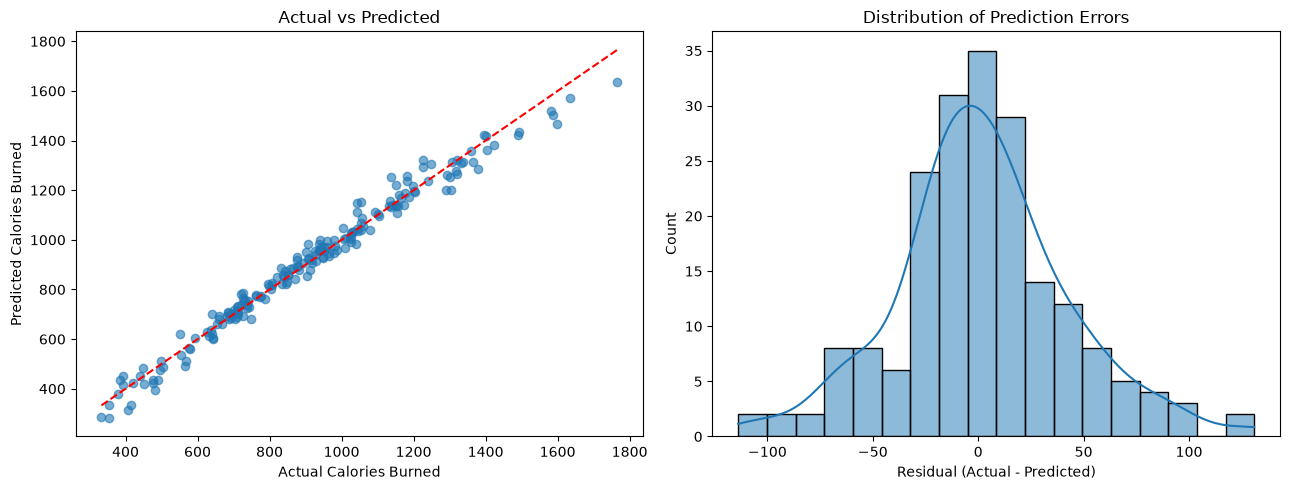

In [24]:
y_pred = model.predict(X_test)
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_test, y_pred, alpha=0.6)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
axes[0].set_xlabel('Actual Calories Burned')
axes[0].set_ylabel('Predicted Calories Burned')
axes[0].set_title('Actual vs Predicted')

sns.histplot(residuals, kde=True, ax=axes[1])
axes[1].set_xlabel('Residual (Actual - Predicted)')
axes[1].set_title('Distribution of Prediction Errors')

plt.tight_layout()
plt.savefig('../images/model_evaluation.png', dpi=150)
plt.show()

## Final Conclusions

- The dataset does not support time-series performance tracking (no repeated measurements per member).
- Redefined the project as a regression problem: predicting Calories_Burned per session.
- Session_Duration is by far the strongest predictor (correlation 0.91, coefficient ~713).
- Linear Regression outperformed Random Forest (R² = 0.98 vs 0.97), suggesting the relationship is largely linear.
- Workout_Type has minimal effect on calories burned.

## Limitations
- The very high R² (0.98) suggests this dataset may be synthetic, as real-world fitness data usually has more noise.
- Single-session snapshot data; results may not generalize to other populations or gym environments.

## Future Improvements
- Test with real-world gym data to validate findings.
- Try additional features like workout intensity or heart rate zones.